# Day 10 — Frame and Intensity EDA

**Project:** Optical Camera Communication (OCC) Video Message Decoding

Everything here is read-only. Nothing in `data/raw/` is changed.

**What this notebook does**

1. Pulls frames and plots brightness against frame number
2. Compares eight ways of turning an ROI into one number, and measures the noise in each
3. Finds the transitions and asks what symbol period fits them
4. Checks ambient light and drift across every recording

**The main result is in section 4, and it is a negative one:** the run lengths in the
video do not match a plain 92 bits-per-second on/off stream. That needs an answer from
the faculty before decoding can be trusted.

> **Note (2026-09-10, audit).** This notebook reads `rois.json` (Day 09) and `audit_<video>.npz` (Day 08), neither of which was committed. Both were regenerated from `../../Videos/`: `rois.json` with `../day09/roi_extract.py` (trims within 3 frames of the values printed below — its trim points are the *window starts* 40 / 778 / 772 / 1610, which Day 11 later corrected to the first lit frame, 217 / 975 / 965 / 1816), and the `.npz` files with `make_audit_npz.py` in this folder, whose definition is stated in its docstring and reproduces the on-levels printed in section 5 exactly. Re-executed with these inputs the notebook reproduces every number below to within one transition. Put the videos in `data/raw/` to run it. Markdown percentages that disagreed with the printed outputs by 0.2–0.3 points have been aligned to the outputs (cells in sections 4 and 6).


In [1]:
import cv2, numpy as np, json
import matplotlib.pyplot as plt
%matplotlib inline

FPS  = 260.0        # measured from the file header and confirmed frames/duration
BPS  = 92.0         # taken from the FILENAME - see section 4, this is in doubt
SPS  = FPS / BPS    # frames per bit

ROIS = json.load(open('rois.json'))   # produced on Day 09
print(f"{FPS} fps / {BPS} bps  ->  {SPS:.4f} frames per bit")
for name, r in ROIS.items():
    print(f"  {name:14s} trim {r['trim'][0]:6d}..{r['trim'][1]:6d}   {len(r['lamps'])} lamp(s)")

260.0 fps / 92.0 bps  ->  2.8261 frames per bit
  1LED_92bps     trim     40.. 28251   1 lamp(s)
  2LEDs_92bps    trim    778.. 18372   2 lamp(s)
  3LEDs_92bps    trim    772.. 12638   3 lamp(s)
  4LEDs_92bps    trim   1610.. 10632   4 lamp(s)


## 1. Frames and brightness over time

We take one number per frame from inside the lamp's box. Section 2 compares the ways of
doing that; here we use the mean of the brightest quarter of the pixels.

In [2]:
def roi_series(name, box, start, n):
    """Mean of the brightest quarter of the pixels inside the box, one value per frame."""
    x, y, w, h = box
    cap = cv2.VideoCapture(f'data/raw/{name}.mp4')
    cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    out = []
    for _ in range(n):
        ok, f = cap.read()
        if not ok: break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)[y:y+h, x:x+w].reshape(-1)
        out.append(np.sort(g)[-g.size//4:].mean())
    cap.release()
    return np.array(out, float)

r    = ROIS['1LED_92bps']
box  = r['lamps'][0]['box']
s    = roi_series('1LED_92bps', box, r['trim'][0] + 500, 20000)
thr  = (np.percentile(s, 10) + np.percentile(s, 90)) / 2
print(f"{len(s)} frames ({len(s)/FPS:.1f} s), brightness {s.min():.0f}..{s.max():.0f}, threshold {thr:.0f}")

20000 frames (76.9 s), brightness 1..251, threshold 126


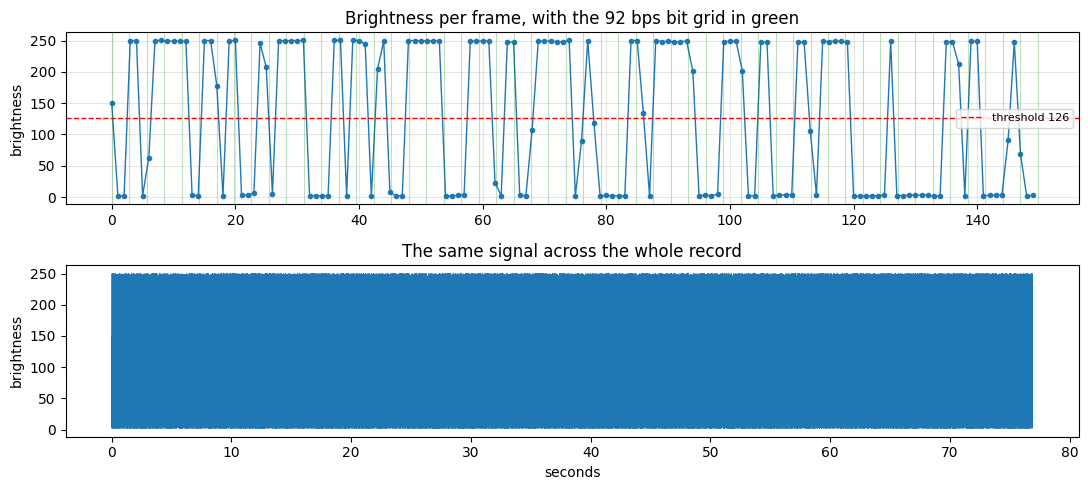

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5))
ax[0].plot(s[:150], '-o', ms=3, lw=1)
ax[0].axhline(thr, color='r', ls='--', lw=1, label=f'threshold {thr:.0f}')
for k in np.arange(0, 150, SPS):
    ax[0].axvline(k, color='g', alpha=.25, lw=.8)
ax[0].set_title('Brightness per frame, with the 92 bps bit grid in green')
ax[0].set_ylabel('brightness'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(np.arange(len(s))/FPS, s, lw=.3)
ax[1].set_title('The same signal across the whole record')
ax[1].set_xlabel('seconds'); ax[1].set_ylabel('brightness')
plt.tight_layout(); plt.show()

The signal is almost binary: it sits at 0 or about 245 with a wide empty gap. The few
middle values are frames whose exposure straddled a bit boundary.

Look closely at the top panel. Some of the level changes do **not** land on a green line.
That is the thread we pull in section 4.

## 2. Which ROI statistic should we use?

Eight candidates. For each one we put the values on a common 0-255 scale, then measure:

- **gap** — distance between the clearly-on and clearly-off groups
- **noise** — how much the values wobble *within* each group
- **gap / noise** — higher is better

Only clearly-on and clearly-off samples are used, so mid-transition frames do not
pollute the noise figure.

In [4]:
def load_patch(name, box, start, n):
    x, y, w, h = box
    cap = cv2.VideoCapture(f'data/raw/{name}.mp4'); cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    out = []
    for _ in range(n):
        ok, f = cap.read()
        if not ok: break
        out.append(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)[y:y+h, x:x+w])
    cap.release()
    return np.stack(out)

patch = load_patch('1LED_92bps', box, r['trim'][0] + 500, 4000)
flat  = lambda p: p.reshape(len(p), -1)
brightest = lambda p, frac: np.sort(flat(p), 1)[:, -max(1, p[0].size//frac):].mean(1)

STATS = {
    'mean of all pixels'    : lambda p: flat(p).mean(1),
    'median pixel'          : lambda p: np.median(flat(p), 1),
    'max pixel'             : lambda p: flat(p).max(1),
    '90th percentile'       : lambda p: np.percentile(flat(p), 90, axis=1),
    'mean of brightest 10%' : lambda p: brightest(p, 10),
    'mean of brightest 25%' : lambda p: brightest(p, 4),
    'mean of brightest 50%' : lambda p: brightest(p, 2),
    'count of pixels > 128' : lambda p: (flat(p) > 128).sum(1).astype(float),
}

rows = []
for nm, fn in STATS.items():
    v = fn(patch).astype(float)
    v = (v - v.min()) / (v.max() - v.min()) * 255          # common scale
    t = (np.percentile(v, 10) + np.percentile(v, 90)) / 2
    on, off = v[v > t + 60], v[v < t - 60]                 # clearly on / clearly off
    gap   = on.mean() - off.mean()
    noise = np.sqrt((on.std()**2 + off.std()**2) / 2)
    rows.append((nm, gap, on.std(), off.std(), gap/noise))

print(f"{'statistic':24s} {'gap':>7s} {'noise ON':>9s} {'noise OFF':>10s} {'gap/noise':>10s}")
for nm, gap, no, nf, snr in rows:
    print(f"{nm:24s} {gap:7.1f} {no:9.2f} {nf:10.2f} {snr:10.1f}")

statistic                    gap  noise ON  noise OFF  gap/noise
mean of all pixels         243.1     10.69       9.31       24.3
median pixel               248.5      9.50       6.94       29.9
max pixel                  248.9      8.54       6.30       33.2
90th percentile            248.1      8.29       7.18       32.0
mean of brightest 10%      247.8      8.71       7.08       31.2
mean of brightest 25%      247.9      8.49       7.10       31.7
mean of brightest 50%      247.6      9.35       7.56       29.1
count of pixels > 128      248.1      9.70       6.52       30.0


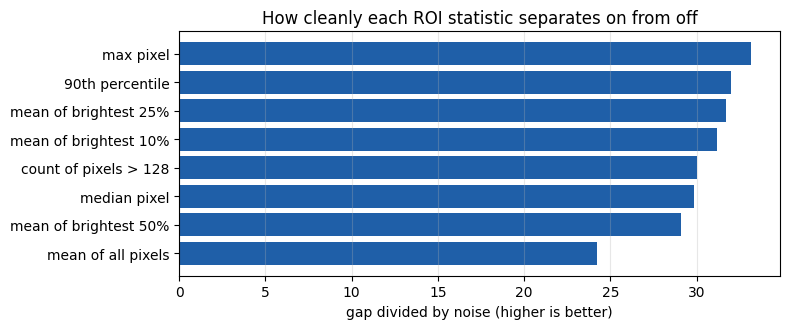

In [5]:
names = [x[0] for x in rows]; snrs = [x[4] for x in rows]
order = np.argsort(snrs)
plt.figure(figsize=(8, 3.4))
plt.barh([names[i] for i in order], [snrs[i] for i in order], color='#1f5fa8')
plt.xlabel('gap divided by noise (higher is better)')
plt.title('How cleanly each ROI statistic separates on from off')
plt.grid(alpha=.3, axis='x'); plt.tight_layout(); plt.show()

**What this says.** Every statistic works. The gap is about 245 grey levels and the
noise is 6 to 11, so all eight land between 24 and 33 — the signal is so strong that the
choice barely matters.

The plain **mean of all pixels** is the weakest, because dark pixels in the corners of the
box water it down. Anything that focuses on the bright pixels does better.

We keep **mean of the brightest 25%**. It is near the top, and unlike `max pixel` it
averages over many pixels, so a single hot pixel cannot swing it. `max pixel` scoring well
here is a property of this clean dataset, not a reason to trust it in general.

Note this is a **noise** comparison, not a correctness one. Without ground truth we cannot
say which statistic yields the right bits — only which separates the two levels most
cleanly.

## 3. Transitions

A transition is a frame where the signal crosses the threshold. The gap between
consecutive transitions is how long the lamp held one level.

In [6]:
binary = (s > thr).astype(np.int8)
edges  = np.flatnonzero(np.diff(binary)) + 1
gaps   = np.diff(edges)

print(f"{len(edges)} transitions in {len(s)} frames -> one every {len(s)/len(edges):.2f} frames")
print(f"mean gap {gaps.mean():.2f} frames = {gaps.mean()/SPS:.2f} bits")
print("(random on/off data would average 2.00 bits between transitions)")
u, c = np.unique(gaps, return_counts=True)
print("\nrun lengths:", dict(zip(u[:10].tolist(), c[:10].tolist())))

5949 transitions in 20000 frames -> one every 3.36 frames
mean gap 3.36 frames = 1.19 bits
(random on/off data would average 2.00 bits between transitions)

run lengths: {1: 537, 2: 2466, 3: 913, 4: 817, 5: 343, 6: 392, 7: 127, 8: 125, 9: 54, 10: 16}


### Are the 1-frame runs just noise?

A value sitting near the threshold could cross back and forth and invent transitions. The
usual guard is hysteresis: require the signal to move well past the threshold before
accepting a change. If the short runs are noise, hysteresis removes them.

In [7]:
lo, hi = np.percentile(s, 10), np.percentile(s, 90)

def schmitt(sig, t, band):
    out = np.empty(len(sig), np.int8)
    state = 1 if sig[0] > t else 0
    for i, v in enumerate(sig):
        if   state == 0 and v > t + band: state = 1
        elif state == 1 and v < t - band: state = 0
        out[i] = state
    return out

for frac in (0.0, 0.15, 0.25, 0.35):
    b = schmitt(s, thr, frac*(hi-lo))
    g = np.diff(np.flatnonzero(np.diff(b)))
    print(f"hysteresis {frac:>5.0%} of range : {len(g):5d} runs, "
          f"{np.mean(g==1)*100:4.1f}% are 1 frame, mean run {g.mean():.2f} frames")

hysteresis    0% of range :  5948 runs,  9.0% are 1 frame, mean run 3.36 frames
hysteresis   15% of range :  5936 runs,  8.7% are 1 frame, mean run 3.37 frames
hysteresis   25% of range :  5926 runs,  8.7% are 1 frame, mean run 3.37 frames
hysteresis   35% of range :  5918 runs,  8.7% are 1 frame, mean run 3.38 frames


**They are not noise.** Widening the hysteresis band all the way to 35% of the signal
range changes almost nothing — the count of 1-frame runs stays at about 8.7%. These short
runs are really in the data.

## 4. What symbol period fits? — the main finding

If the stream really were 92 bits per second, one bit would last 2.826 frames. Then:

| bits held | frames |
|---|---|
| 1 bit | 2.826 -> seen as 2 or 3 frames |
| 2 bits | 5.65 -> seen as 5 or 6 frames |
| 3 bits | 8.48 -> seen as 8 or 9 frames |

Runs of **4** or **7** frames are impossible. So are runs of 1 frame.

Let us compare that prediction against the video.

In [8]:
rng = np.random.default_rng(1)

def simulate(T, N=20000):
    """What the camera would record from random on/off bits of period T.
    Each frame integrates the light over its own exposure, so a frame that
    straddles a bit boundary lands part way - exactly what we observe."""
    nb    = int(N/T) + 4
    bits  = rng.integers(0, 2, nb).astype(float)
    edge  = np.arange(nb+1) * T
    fr    = np.empty(N)
    for n in range(N):
        k0, k1 = int(n//T), int(min((n+1)//T, nb-1))
        tot = 0.0
        for k in range(k0, k1+1):
            a, b_ = max(n, edge[k]), min(n+1, edge[k+1])
            if b_ > a: tot += bits[k] * (b_ - a)
        fr[n] = tot
    return np.diff(np.flatnonzero(np.diff((fr > 0.5).astype(np.int8))))

K   = 10
g92 = simulate(SPS)
obs = np.bincount(np.clip(gaps, 0, K), minlength=K+1)[1:K+1] / len(gaps)
pred= np.bincount(np.clip(g92,  0, K), minlength=K+1)[1:K+1] / len(g92)

print(f"{'run (frames)':>13s} {'real video':>11s} {'92 bps model':>13s}")
for i in range(K):
    print(f"{i+1:13d} {obs[i]*100:10.1f}% {pred[i]*100:12.1f}%")
print(f"\nmean run: real {gaps.mean():.2f} frames, 92 bps model {g92.mean():.2f} frames")

 run (frames)  real video  92 bps model
            1        9.0%          0.0%
            2       41.5%          8.9%
            3       15.3%         41.1%
            4       13.7%          0.0%
            5        5.8%          9.1%
            6        6.6%         16.1%
            7        2.1%          0.0%
            8        2.1%          5.6%
            9        0.9%          6.1%
           10        2.9%         13.0%

mean run: real 3.36 frames, 92 bps model 5.71 frames


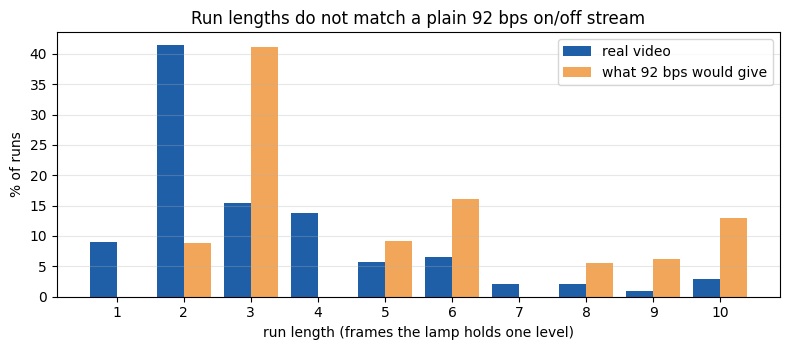

In [9]:
xs = np.arange(1, K+1); w = 0.4
plt.figure(figsize=(8, 3.6))
plt.bar(xs - w/2, obs*100,  w, label='real video',               color='#1f5fa8')
plt.bar(xs + w/2, pred*100, w, label='what 92 bps would give',   color='#F2A65A')
plt.xlabel('run length (frames the lamp holds one level)'); plt.ylabel('% of runs')
plt.title('Run lengths do not match a plain 92 bps on/off stream')
plt.xticks(xs); plt.legend(); plt.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()

### The mismatch

Three things disagree, and they are not small:

1. **Runs of 4 frames are 13.7% of the real data.** At 92 bps they are impossible.
2. **Runs of 1 frame are 9.0% of the real data** (8.7% after hysteresis). Also impossible, and
   hysteresis proved they are not noise.
3. **The mean run is 3.36 frames in the video, against 5.71 in the model.** The real
   signal changes level far more often than 92 bps random data would.

The model bars sit at 3, 6 and 9 frames — exactly the multiples of 2.826 — while the real
bars are spread across 2, 3, 4 and beyond. The two distributions are a different shape,
not a noisy version of each other.

### Can we recover the rate from the video instead?

Three estimators were tried. **All three failed**, and the reason is worth recording.

In [10]:
# A) spectral null - random on/off data has a dip at the symbol rate
x_ = s - s.mean(); n = len(x_)//4*4
sp = np.zeros(n//8 + 1)
for k in range(4):
    seg = x_[k*(n//4):(k+1)*(n//4)]
    sp += np.abs(np.fft.rfft(seg * np.hanning(len(seg))))**2
fr_ = np.fft.rfftfreq(n//4, 1/FPS)
band = (fr_ > 50) & (fr_ < 128)
sm = np.convolve(sp, np.ones(9)/9, mode='same')
print(f"A) spectral null  -> {fr_[band][np.argmin(sm[band])]:.1f} Hz")

# B) do the transitions sit on a regular grid?
best = max(((abs(np.mean(np.exp(2j*np.pi*(edges % T)/T))), T)
            for T in np.arange(2.0, 6.0, 0.002)))
print(f"B) transition grid-> {FPS/best[1]:.1f} bps  (grid tightness only {best[0]:.2f} - very loose)")

# C) sweep the assumed period and score the sampling
def score(T):
    c = np.arange(T/2, len(s)-1, T)
    v = s[np.round(c).astype(int)]
    return np.mean(np.abs(v - thr) < 40) * 100
Ts = np.arange(2.0, 6.0, 0.005); q = np.array([score(T) for T in Ts])
print(f"C) period sweep   -> {FPS/Ts[np.argmin(q)]:.1f} bps")
print(f"\nfilename claims   -> {BPS:.1f} bps")

A) spectral null  -> 119.2 Hz


B) transition grid-> 127.6 bps  (grid tightness only 0.14 - very loose)
C) period sweep   -> 44.3 bps

filename claims   -> 92.0 bps


**Why they all fail.** At 2.83 frames per bit we are barely above the sampling limit of
2. A transition that truly happens at time 12.4 is recorded as an edge at frame 12 or 13,
so its timing is uncertain by up to half a frame — nearly a fifth of a bit. That smears
every timing-based estimator.

Estimators B and C are also biased toward larger periods: the longer the assumed bit, the
fewer samples land near a transition, so they score well for the wrong reason. Their
"answers" of 128 and 44 bps should be read as *the method failed*, not as measurements
(estimator C returned 67 bps on a re-run with regenerated inputs — it is unstable, which
makes the same point).

**So we cannot confirm the bit rate from the video.** We are taking 92 bps from the
filename, and the run lengths disagree with it.

### What could explain it

Listed without picking one — we do not have the evidence to choose:

| Possibility | Fits? |
|---|---|
| The rate is not 92 bps | Would explain everything, but no estimator could confirm a better value |
| A line code sits on top (more transitions by design) | Fits the excess transitions. But a Manchester test came back at 47% (48% on the Signal V1 bits), not the 100% Manchester requires |
| 92 bps is the *payload* rate after coding, with a faster raw rate | Consistent with a mean run shorter than the model, and untestable without the format |
| The lamp has a slow rise or fall, splitting runs | Hysteresis ruled out threshold noise, but not a real physical ramp |

This is question **Q2** from Day 09, and it has moved from an open question to a blocking
one: we now have positive evidence that something sits between the raw bits and the light.

## 5. Ambient light and drift

Day 08 measured this across every frame of every video. Here is the summary.

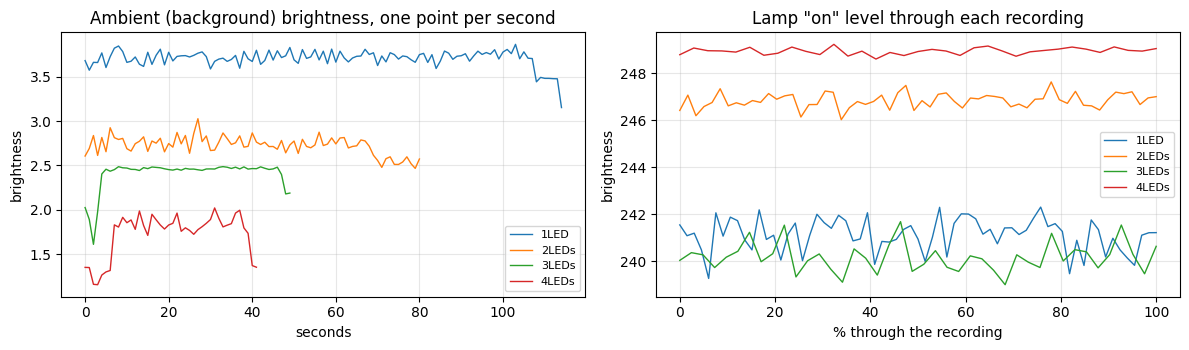

1LED_92bps     on-level first half  241.1 | second half  241.1 | drift -0.00
2LEDs_92bps    on-level first half  246.8 | second half  246.9 | drift +0.13
3LEDs_92bps    on-level first half  240.2 | second half  240.1 | drift -0.08
4LEDs_92bps    on-level first half  248.9 | second half  249.0 | drift +0.09


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for name in ROIS:
    d = np.load(f'audit_{name}.npz')
    amb = d['amb']; blk = int(FPS); nb = len(amb)//blk
    ax[0].plot(amb[:nb*blk].reshape(nb, blk).mean(1), lw=1, label=name.replace('_92bps',''))
    on = d['on_lvl']; nb2 = len(on)//200
    ax[1].plot(np.linspace(0, 100, nb2), on[:nb2*200].reshape(nb2, 200).mean(1), lw=1,
               label=name.replace('_92bps',''))
ax[0].set_title('Ambient (background) brightness, one point per second')
ax[0].set_xlabel('seconds'); ax[0].set_ylabel('brightness'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].set_title('Lamp "on" level through each recording')
ax[1].set_xlabel('% through the recording'); ax[1].set_ylabel('brightness')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

for name in ROIS:
    d = np.load(f'audit_{name}.npz'); on = d['on_lvl']; h = len(on)//2
    print(f"{name:14s} on-level first half {on[:h].mean():6.1f} | second half {on[h:].mean():6.1f} "
          f"| drift {on[h:].mean()-on[:h].mean():+5.2f}")

**There is no drift worth correcting.** The lamp's on-level moves by at most 0.13 grey
levels between the first and second half of a recording, against a contrast of about 245.
Ambient background sits between 1.8 and 3.5 and varies by well under one grey level per
second.

This confirms the Day 09 decision to leave detrending and normalising switched **off** for
this dataset. They stay in the code behind config flags, and their value gets shown on
synthetic videos where we control the drift ourselves.

## 6. What we learned

**Settled**

- All eight ROI statistics work; the signal is far too strong for the choice to matter.
  Mean of the brightest 25% is kept for its resistance to single hot pixels.
- Noise inside a level is 6 to 11 grey levels against a gap of about 245.
- There is no ambient drift and no lamp drift. Detrending stays off.
- The short runs are real, not threshold noise — hysteresis does not remove them.

**Not settled, and now blocking**

- The run lengths do not match a plain 92 bps stream. Runs of 1 and 4 frames make up
  22.7% of the runs in `1LED` (9.0% + 13.7%) and should not exist at all. On the nine
  multi-lamp signals of Signal V1 the share is 25–27%, with 1-frame runs at 14–18%.
- The bit rate cannot be recovered from the video by any estimator we tried, because at
  2.83 frames per bit the timing of each transition is uncertain by nearly a fifth of a bit.
- So the bit rate rests entirely on the filename, and the data argues against it.

**What we need**

1. The transmitted bits, for at least one video (Q1).
2. The format sitting above the raw bits — preamble, line coding, anything (Q2).
3. Confirmation of the bit rate and whether 92 bps is the payload rate or the light's
   switching rate (Q3).

Until then, any decoded message would be a guess we have no way to check.